In [1]:
import pandas as pd
import numpy as np

In [2]:
data=pd.read_csv('/Users/alevaldivia/Downloads/Lab_3/Advertising.csv')
data.shape

(200, 5)

In [ ]:
head = data.head()
tail = data.tail()
describe = data.describe()
print(head) #Primera 5 filas del dataset
print(tail) #Últimas 5 filas del dataset
print(describe) #Estadísticas descriptivas del dataset

   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
     Unnamed: 0     TV  radio  newspaper  sales
195         196   38.2    3.7       13.8    7.6
196         197   94.2    4.9        8.1    9.7
197         198  177.0    9.3        6.4   12.8
198         199  283.6   42.0       66.2   25.5
199         200  232.1    8.6        8.7   13.4
       Unnamed: 0          TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.90000

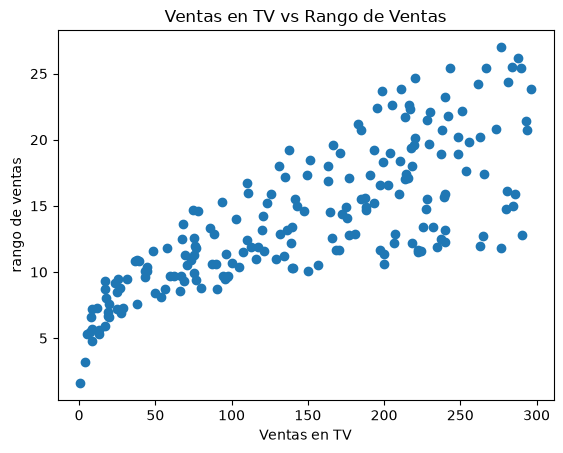

In [6]:
import matplotlib.pyplot as plt
plt.scatter(data['TV'], data['sales'])
plt.xlabel('Ventas en TV')
plt.ylabel('rango de ventas')
plt.title('Ventas en TV vs Rango de Ventas')
plt.show()

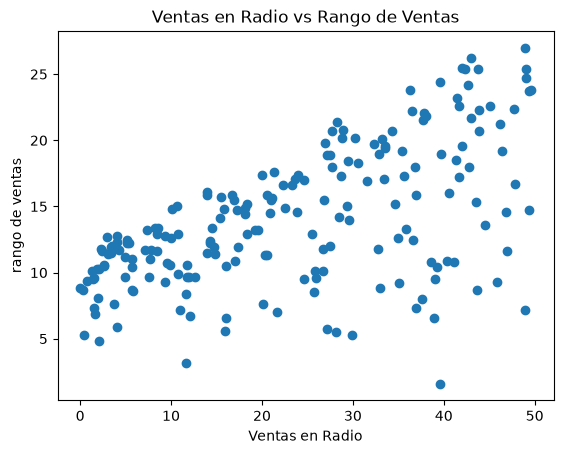

In [7]:
import matplotlib.pyplot as plt
plt.scatter(data['radio'], data['sales'])
plt.xlabel('Ventas en Radio')
plt.ylabel('rango de ventas')
plt.title('Ventas en Radio vs Rango de Ventas')
plt.show()

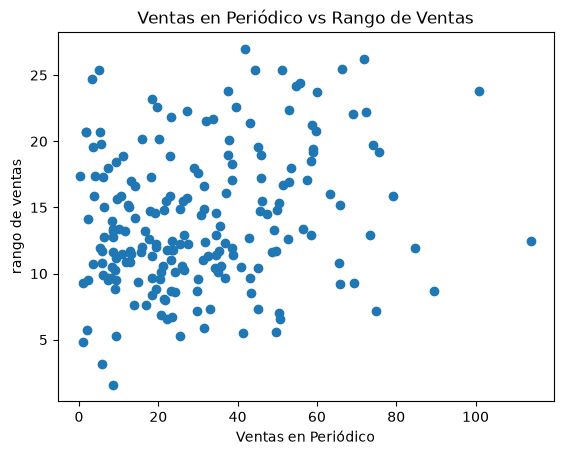

In [8]:
import matplotlib.pyplot as plt
plt.scatter(data['newspaper'], data['sales'])
plt.xlabel('Ventas en Periódico')
plt.ylabel('rango de ventas')
plt.title('Ventas en Periódico vs Rango de Ventas')
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [12]:
lr = LinearRegression()
x=data[['TV']]
y=data['sales']
lr.fit(x,y)
print(lr.intercept_)
print(lr.coef_)

7.0325935491276885
[0.04753664]


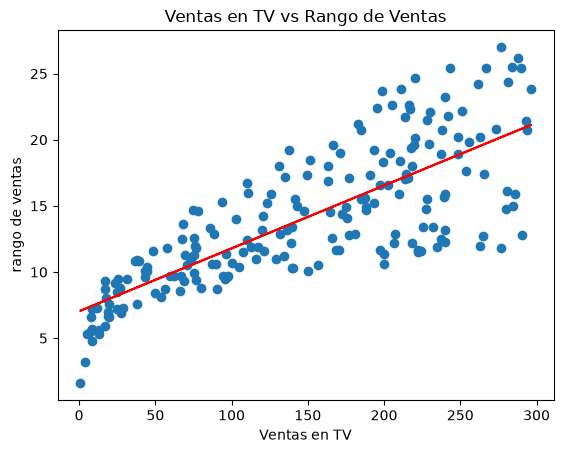

In [16]:
pred=lr.predict(x)

plt.scatter(data['TV'], data['sales'])
plt.plot(data['TV'], pred, color='red') 
plt.xlabel('Ventas en TV')
plt.ylabel('rango de ventas')
plt.title('Ventas en TV vs Rango de Ventas')
plt.show()

In [25]:
# Errores del modelo
error = y - pred

# RSS = suma de los errores al cuadrado
RSS = np.sum(error**2)

# Numero de datos
n = len(y)

# p = numero de parametros del modelo
# beta 0 y beta 1
p = 2

# Varianza del error
sigma2 = RSS / (n - p)

# Promedio de x
x_prom = data['TV'].mean()

# Suma de (xi - x_prom)^2
suma_x = np.sum((data['TV'] - x_prom)**2)

# Error estandar de beta 1 al cuadrado
SE_B1_2 = sigma2 / suma_x

# Error estandar de beta 1
SE_B1 = np.sqrt(SE_B1_2)

# Error estandar de beta 0 al cuadrado
SE_B0_2 = sigma2 * ((1/n) + (x_prom**2 / suma_x))

# Error estandar de beta 0
SE_B0 = np.sqrt(SE_B0_2)

print('RSS:', RSS)
print('Promedio de x:', x_prom)
print('Suma de (xi - x_prom)^2:', suma_x)
print('Varianza del error:', sigma2)
print('Error beta 1:', SE_B1)
print('Error beta 0:', SE_B0)

RSS: 2102.5305831313512
Promedio de x: 147.0425
Suma de (xi - x_prom)^2: 1466819.02875
Varianza del error: 10.618841328946218
Error beta 1: 0.0026906071877968707
Error beta 0: 0.4578429402734785


In [26]:
# Estadistico t para beta 0
t_B0 = lr.intercept_ / SE_B0

# Estadistico t para beta 1
t_B1 = lr.coef_[0] / SE_B1

print('t beta 0:', t_B0)
print('t beta 1:', t_B1)

# Intervalo de confianza 95% para beta 1
IC_B1_inf = lr.coef_[0] - 2*SE_B1
IC_B1_sup = lr.coef_[0] + 2*SE_B1

# Intervalo de confianza 95% para beta 0
IC_B0_inf = lr.intercept_ - 2*SE_B0
IC_B0_sup = lr.intercept_ + 2*SE_B0

print('IC 95% beta 1:', IC_B1_inf, IC_B1_sup)
print('IC 95% beta 0:', IC_B0_inf, IC_B0_sup)

t beta 0: 15.360275174117534
t beta 1: 17.66762560087556
IC 95% beta 1: 0.04215542605742605 0.05291785480861353
IC 95% beta 0: 6.1169076685807315 7.9482794296746455


In [29]:
from scipy import stats
p_bi=2*(1 - stats.t.cdf(np.abs(t_B1), df=n-p))
print('p-value beta 1:', p_bi)

p_b0=2*(1 - stats.t.cdf(np.abs(t_B0), df=n-p))
print('p-value beta 0:', p_b0)

p-value beta 1: 0.0
p-value beta 0: 0.0
